Dataset shape: (800, 64)

Explained Variance Ratio:
PCA with 2 components → 0.2246
PCA with 10 components → 0.6117
PCA with 30 components → 0.9066
PCA with 50 components → 0.9873


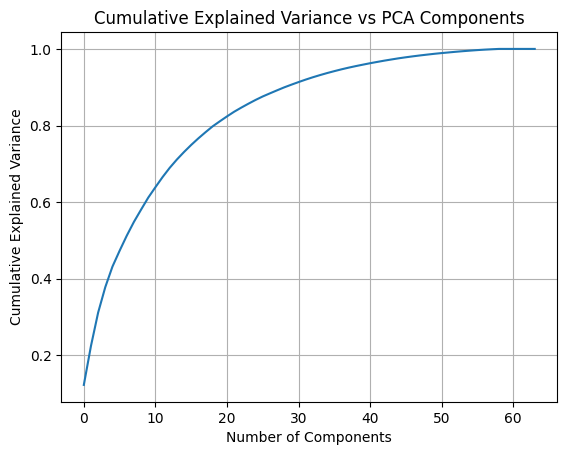

Reduced dataset shape: (800, 30)

Accuracy Comparison:
Original Dataset Accuracy : 0.95625
PCA Reduced Dataset Accuracy : 0.95625


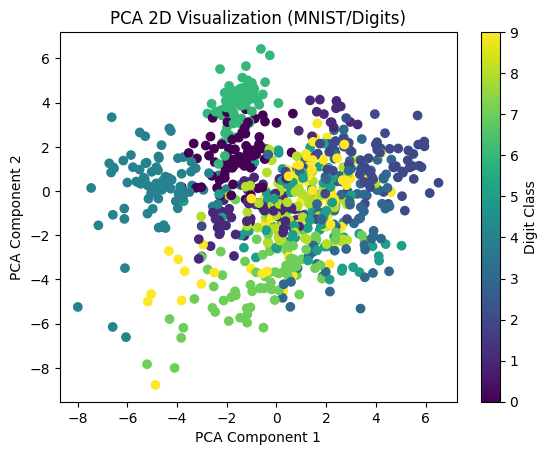

In [1]:
# =====================================================
# 1. Load MNIST / Digits dataset from CSV and flatten
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset (CSV)
data = pd.read_csv("/content/mnist_data.csv")

# Separate features and labels
X = data.drop("label", axis=1)
y = data["label"]

print("Dataset shape:", X.shape)

# =====================================================
# 2. Scale features using StandardScaler
# =====================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================
# 3. Apply PCA with multiple component counts
# =====================================================

pca_components = [2, 10, 30, 50]
explained_variance = {}

for n in pca_components:
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance[n] = np.sum(pca.explained_variance_ratio_)

# =====================================================
# 4. Track explained variance ratio
# =====================================================

print("\nExplained Variance Ratio:")
for k, v in explained_variance.items():
    print(f"PCA with {k} components → {v:.4f}")

# =====================================================
# 5. Plot cumulative explained variance
# =====================================================

pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure()
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs PCA Components")
plt.grid(True)
plt.show()

# =====================================================
# 6. Transform dataset using selected PCA
# (Choosing 30 components)
# =====================================================

pca_selected = PCA(n_components=30)
X_pca = pca_selected.fit_transform(X_scaled)

print("Reduced dataset shape:", X_pca.shape)

# =====================================================
# 7. Train Logistic Regression on PCA-reduced data
# =====================================================

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

lr_pca = LogisticRegression(max_iter=3000)
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)
pca_accuracy = accuracy_score(y_test, y_pred_pca)

# =====================================================
# 8. Train Logistic Regression on original dataset
# =====================================================

X_train_org, X_test_org, y_train_org, y_test_org = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

lr_org = LogisticRegression(max_iter=3000)
lr_org.fit(X_train_org, y_train_org)

y_pred_org = lr_org.predict(X_test_org)
org_accuracy = accuracy_score(y_test_org, y_pred_org)

print("\nAccuracy Comparison:")
print("Original Dataset Accuracy :", org_accuracy)
print("PCA Reduced Dataset Accuracy :", pca_accuracy)

# =====================================================
# 9. PCA 2D Scatter Plot
# =====================================================

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure()
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA 2D Visualization (MNIST/Digits)")
plt.colorbar(scatter, label="Digit Class")
plt.show()
